# nb01 — Data and baselines

Phase 2 of `llm-regime-allocator`. Everything here is read from files written by `python scripts/run_baselines.py`; nothing is fitted in this notebook.

**Setup.** Monthly decisions at month-end close, 2007-12-31 → 2026-04-30 (221 holding months). Investable: SPY, EEM, IEF, TIP, HYG, DBC, GLD, BIL. Costs 2.5 bps on traded notional; Sharpe in excess of BIL. All signals point-in-time (ALFRED vintages, release lags); ML is walk-forward with labels only once published.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
R = Path('../results/baselines')
REG = ['Goldilocks', 'Reflation', 'Stagflation', 'Risk_Off']
# reference categorical palette (light), fixed order
C = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'lines.linewidth': 2,
                     'axes.edgecolor': '#52514e', 'text.color': '#0b0b0b'})
met = pd.read_csv(R / 'metrics.csv')
reg = pd.read_csv(R / 'regimes.csv', parse_dates=['date'], index_col='date')
daily = pd.read_csv(R / 'daily_returns.csv', parse_dates=[0], index_col=0)
feat = pd.read_csv(R / 'features.csv', parse_dates=['date'], index_col='date')

## 1. Context pack

One row per decision date: 13 macro indicators × (level, 3m change, 12m change, 36m z-score) and 7 market roles × (1/3/6/12m return, 6m vol, 12m drawdown) plus the 6m stock–bond correlation. Feature names carry roles, never tickers or dates.

In [2]:
print(feat.shape)
cov = feat.notna().mean().groupby(lambda c: c.split('_')[0]).mean()
print('share of non-missing values by block:'); print(cov.round(3))
feat.loc['2008-09-30'].filter(like='macro_').filter(like='_level').round(2)

(282, 95)
share of non-missing values by block:
macro    0.980
mkt      0.976
dtype: float64


macro_growth_indpro_yoy_level    -1.49
macro_growth_cfnai_ma3_level     -1.06
macro_labour_unrate_level         6.10
macro_labour_payems_3m_level    -81.33
macro_infl_cpi_yoy_level          5.36
macro_infl_core_yoy_level         2.55
macro_policy_ffr_level            1.56
macro_rates_2y_level              1.70
macro_rates_10y_level             3.61
macro_curve_10y2y_level           1.91
macro_risk_vix_level             46.72
macro_credit_baa10y_level         4.01
macro_usd_broad_yoy_level        -0.90
Name: 2008-09-30 00:00:00, dtype: float64

## 2. Regimes

Rule = growth × inflation quadrant from the trailing 6-month trend of the 3-month average of INDPRO YoY and CPI YoY (a persistence forecast). *Realised* = the same quadrant over the **next** 3 months, measured with today's vintage — the target for H1.

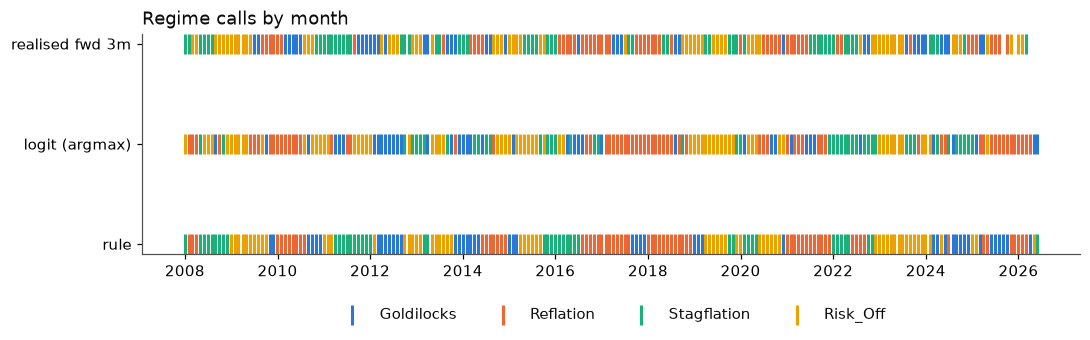

In [3]:
fig, ax = plt.subplots(figsize=(11, 2.6))
rows = {'rule': reg['rule'], 'logit (argmax)': reg[[f'logit_{k}' for k in REG]].idxmax(axis=1).str[6:],
        'realised fwd 3m': reg['realised_forward']}
for y, (name, s) in enumerate(rows.items()):
    for k, c in zip(REG, C):
        d = s.index[s == k]
        ax.scatter(d, [y] * len(d), marker='|', s=180, color=c, label=k if y == 0 else None)
ax.set_yticks(range(len(rows)), list(rows)); ax.grid(False)
ax.legend(ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.18), frameon=False)
ax.set_title('Regime calls by month', loc='left'); plt.show()

In [4]:
ok = reg['realised_forward'].notna()
y = reg.loc[ok, 'realised_forward']
onehot = np.stack([(y == k).astype(float) for k in REG], 1)
def score(p):
    i = [REG.index(v) for v in y]
    return {'hit_rate': (np.array(REG)[p.argmax(1)] == y.values).mean(),
            'brier': ((p - onehot) ** 2).sum(1).mean(),
            'log_loss': -np.log(np.clip(p[np.arange(len(y)), i], 1e-6, 1)).mean()}
# walk-forward climatology: base rates of labels already published (approx.: labels up to t-4)
base = pd.DataFrame(onehot, index=y.index, columns=REG).shift(4).expanding().mean().fillna(0.25)
rule_p = np.stack([(reg.loc[ok, 'rule'] == k).astype(float) for k in REG], 1)
scores = pd.DataFrame({
    'uniform 25% (hit rate = argmax artefact)': score(np.full_like(onehot, 0.25)),
    'climatology (walk-fwd)': score(base.to_numpy()),
    'rule (hard 0/1)': score(rule_p * 0.997 + 0.00075),
    'ml logit': score(reg.loc[ok, [f'logit_{k}' for k in REG]].to_numpy()),
    'ml gbt': score(reg.loc[ok, [f'gbt_{k}' for k in REG]].to_numpy()),
}).T
print(f'{ok.sum()} labelled months'); scores.round(3)

217 labelled months


,hit_rate,brier,log_loss
uniform 25% (hit rate = argmax artefact),0.189,0.750,1.386
climatology (walk-fwd),0.194,0.792,1.764
rule (hard 0/1),0.332,1.332,4.809
ml logit,0.373,0.861,1.837
ml gbt,0.323,0.880,1.730


**Reading.** Forecasting next-quarter growth/inflation direction is hard: hit rates sit modestly above 25%, and the hard 0/1 rule is punished on probabilistic scores. This is the bar the LLM must clear in Phase 4 — in particular the walk-forward climatology on Brier / log-loss.

## 3. Baseline portfolios (net of 2.5 bps)

In [5]:
head = met[met.cost_bps == 2.5].drop(columns='cost_bps').set_index('strategy')
head.round({'ann_return': 3, 'ann_vol': 3, 'sharpe': 3, 'max_drawdown': 3, 'calmar': 2, 'turnover_per_year': 2})

,ann_return,ann_vol,sharpe,max_drawdown,calmar,turnover_per_year
strategy,,,,,,
sixty_forty,0.083,0.111,0.655,-0.319,0.26,0.11
reference_static,0.068,0.102,0.568,-0.316,0.22,0.13
rule_playbook,0.063,0.083,0.620,-0.214,0.29,1.09
ml_logit_playbook,0.064,0.081,0.636,-0.259,0.25,1.20
ml_gbt_playbook,0.068,0.074,0.752,-0.183,0.37,1.51
bl_equilibrium,0.068,0.102,0.568,-0.316,0.22,0.13
bl_momentum,0.091,0.164,0.535,-0.348,0.26,2.76


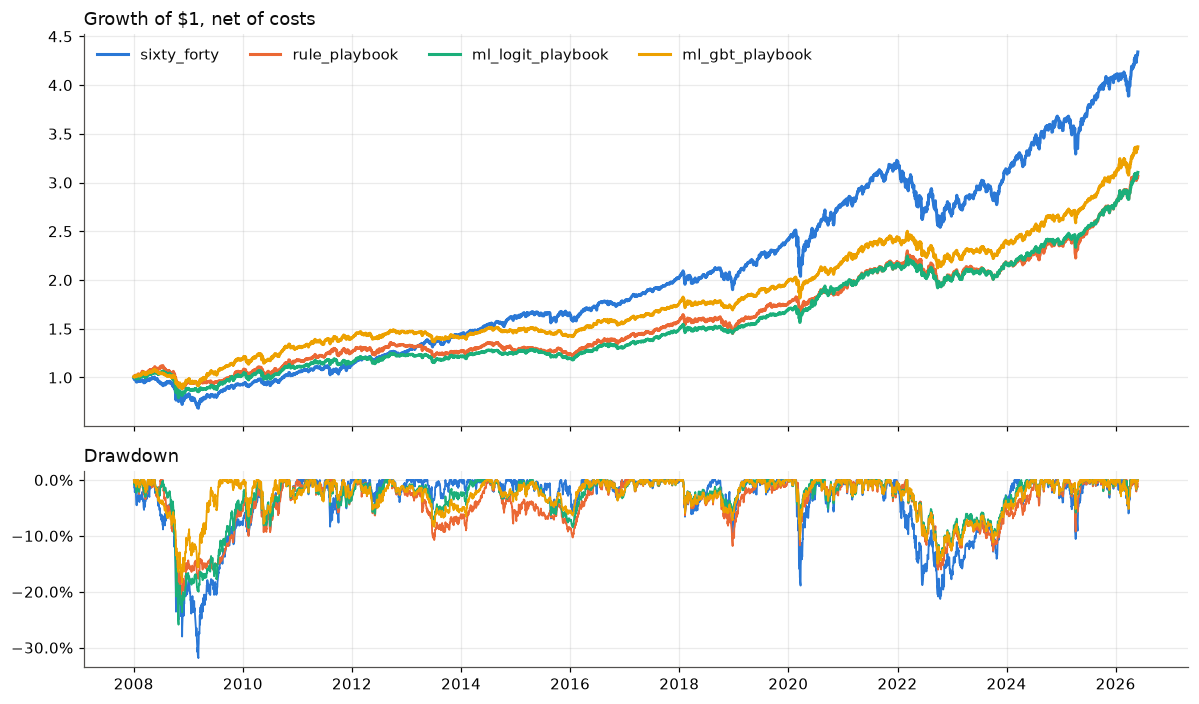

In [6]:
show = ['sixty_forty', 'rule_playbook', 'ml_logit_playbook', 'ml_gbt_playbook']
wealth = (1 + daily[show]).cumprod()
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, height_ratios=[2, 1])
for s, c in zip(show, C):
    a1.plot(wealth.index, wealth[s], color=c, label=s)
    a2.plot(wealth.index, wealth[s] / wealth[s].cummax() - 1, color=c, linewidth=1.2)
a1.set_title('Growth of $1, net of costs', loc='left'); a1.legend(frameon=False, ncol=4, loc='upper left')
a2.set_title('Drawdown', loc='left'); a2.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
plt.tight_layout(); plt.show()

In [7]:
sens = met.pivot(index='strategy', columns='cost_bps', values='sharpe')
sens.columns = [f'{c:g} bps' for c in sens.columns]
print('Sharpe by cost level'); sens.round(3)

Sharpe by cost level


,0 bps,2.5 bps,5 bps,10 bps
strategy,,,,
bl_equilibrium,0.569,0.568,0.568,0.566
bl_momentum,0.543,0.535,0.526,0.509
ml_gbt_playbook,0.762,0.752,0.742,0.722
ml_logit_playbook,0.643,0.636,0.629,0.614
reference_static,0.569,0.568,0.568,0.566
rule_playbook,0.626,0.620,0.613,0.600
sixty_forty,0.656,0.655,0.655,0.654


**Notes.**
* `bl_equilibrium` equals `reference_static` by construction (no views ⇒ BL returns the reference portfolio) — a sanity check, not a strategy.
* Regime playbooks cut volatility and drawdown versus 60/40 at roughly 1–1.5× annual one-way turnover.
* Single path, ~18 years, 221 months: Sharpe differences of this size are within sampling noise (SE of an annualised Sharpe ≈ 0.24 here). Treat the table as the bar, not a ranking.